# 02 — Exploratory Data Analysis (EDA)

## 1. Project Objective & Medical Disclaimer

### Project Objective
The objective of this project is **Disease Diagnosis Prediction Using Clinical Data and Classification Models**.
In this phase, we perform comprehensive Exploratory Data Analysis (EDA) on the heart disease clinical dataset (`data/raw/heart_disease.csv`).

The goal of EDA is to understand:
1. Class distribution and target balance of the binary target variable (`target = (num > 0)`).
2. Univariate distributions and central tendencies of numerical features.
3. Frequency distributions of categorical and boolean clinical attributes.
4. Bivariate associations between input features and heart disease presence.
5. Multicollinearity among numerical features.
6. Detection and classification of statistical outliers using Interquartile Range (IQR) analysis.
7. Data quality, structural zeroes, and unexpected values.

### Medical & Ethical Disclaimer
> **IMPORTANT NOTICE:** This codebase and analysis are developed strictly for **educational and machine-learning research purposes**. This application is **NOT a clinically validated diagnostic system** and must **NEVER** be used to make clinical medical decisions, replace professional medical evaluation, or diagnose patients.


## 2. Load and Inspect Data

We import standard analytical libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and load the raw dataset using `src.data_loader`.
Path resolution logic ensures `src` is cleanly importable.


In [1]:
import sys
from pathlib import Path

# Locate project root containing src/
root_dir = Path.cwd()
for p in [root_dir] + list(root_dir.parents):
    if (p / 'src' / 'config.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATASET_PATH,
    RAW_COLUMNS,
    NUMERICAL_FEATURES,
    CATEGORICAL_FEATURES,
    BOOLEAN_FEATURES,
    FIGURES_DIR,
)
from src.data_loader import load_raw_data, create_binary_target, load_model_data

# Ensure figures output directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

# Load raw data and create binary target
df_raw = load_raw_data()
df = create_binary_target(df_raw)

print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Total Missing Values: {df.isna().sum().sum()}")


Dataset Shape: 918 rows x 12 columns
Duplicate Rows: 0
Total Missing Values: 0


In [2]:
# Display first 10 rows
df.head(10)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0,0
5,56,Male,typical angina,120.0,236.0,False,normal,178.0,False,0.8,0,0
6,62,Female,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,3,1
7,57,Female,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,0,0
8,63,Male,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,2,1
9,53,Male,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,1,1


In [3]:
# Display column data types
df.dtypes


age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
num           int64
target        int64
dtype: object

## 3. Target Analysis

We analyze both the original multi-class target (`num`: 0 to 4) and the derived binary target (`target`: 0 = No Heart Disease, 1 = Heart Disease).


--- Original 'num' Distribution ---
 Diagnosis Severity (num)  Count  Percentage (%)
                        0    410           44.66
                        1    265           28.87
                        2    108           11.76
                        3    107           11.66
                        4     28            3.05


C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\3359757610.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=num_counts.index, y=num_counts.values, palette="Blues_d", ax=ax)


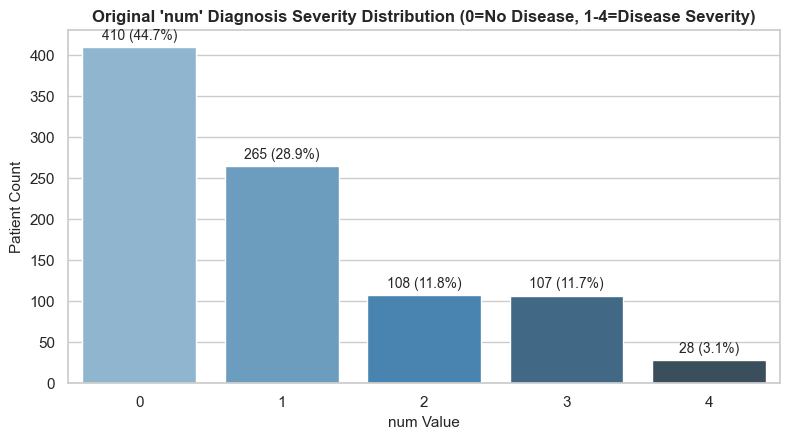

In [4]:
# 1. Original 'num' Distribution
num_counts = df['num'].value_counts().sort_index()
num_pct = df['num'].value_counts(normalize=True).sort_index() * 100

num_df = pd.DataFrame({
    'Diagnosis Severity (num)': num_counts.index,
    'Count': num_counts.values,
    'Percentage (%)': num_pct.round(2).values
})
print("--- Original 'num' Distribution ---")
print(num_df.to_string(index=False))

# Plot Original 'num' Distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=num_counts.index, y=num_counts.values, palette="Blues_d", ax=ax)
ax.set_title("Original 'num' Diagnosis Severity Distribution (0=No Disease, 1-4=Disease Severity)", fontsize=12, fontweight="bold")
ax.set_xlabel("num Value", fontsize=11)
ax.set_ylabel("Patient Count", fontsize=11)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "num_distribution.png", dpi=300)
plt.show()


--- Binary Target Distribution ---
         Class Label  Count  Percentage (%)
No Heart Disease (0)    410           44.66
   Heart Disease (1)    508           55.34

Class Imbalance Ratio (Positive : Negative): 1.24 : 1


C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\2870445060.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["No Heart Disease (0)", "Heart Disease (1)"], y=[target_counts[0], target_counts[1]], palette=colors, ax=ax)


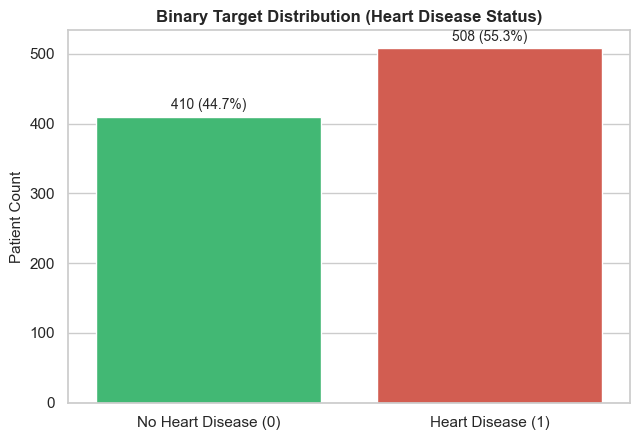

In [5]:
# 2. Binary 'target' Distribution
target_counts = df['target'].value_counts().sort_index()
target_pct = df['target'].value_counts(normalize=True).sort_index() * 100

target_df = pd.DataFrame({
    'Class Label': ['No Heart Disease (0)', 'Heart Disease (1)'],
    'Count': [target_counts[0], target_counts[1]],
    'Percentage (%)': [target_pct[0].round(2), target_pct[1].round(2)]
})
print("--- Binary Target Distribution ---")
print(target_df.to_string(index=False))

# Calculate Imbalance Ratio
imbalance_ratio = target_counts[1] / target_counts[0]
print(f"\nClass Imbalance Ratio (Positive : Negative): {imbalance_ratio:.2f} : 1")

# Plot Binary Target Distribution
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = ["#2ecc71", "#e74c3c"]
sns.barplot(x=["No Heart Disease (0)", "Heart Disease (1)"], y=[target_counts[0], target_counts[1]], palette=colors, ax=ax)
ax.set_title("Binary Target Distribution (Heart Disease Status)", fontsize=12, fontweight="bold")
ax.set_ylabel("Patient Count", fontsize=11)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=300)
plt.show()


### Class Imbalance Assessment
- **Class 0 (No Heart Disease):** 410 patients (44.66%)
- **Class 1 (Heart Disease):** 508 patients (55.34%)
- **Imbalance Ratio:** $1.24 : 1$

**Classification:** The dataset exhibits an **approximately balanced** class distribution.
Because the class ratio is close to 1:1 ($1.24:1$), synthetic resampling techniques (such as SMOTE, random oversampling, or random undersampling) are **NOT required** and will not be applied. Stratified cross-validation during modeling will sufficiently maintain class proportions.


## 4. Numerical Feature Analysis

We analyze the central tendencies, dispersion, and distributions of the 5 numerical features:
- `age`: Patient age in years
- `trestbps`: Resting blood pressure (mm Hg)
- `chol`: Serum cholesterol (mg/dl)
- `thalch`: Maximum heart rate achieved
- `oldpeak`: ST depression induced by exercise relative to rest


In [6]:
# Compute Summary Statistics for Numerical Features
num_stats = df[NUMERICAL_FEATURES].describe().T
num_stats['median'] = df[NUMERICAL_FEATURES].median()
num_stats['IQR'] = num_stats['75%'] - num_stats['25%']

# Reorder columns
num_stats = num_stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'IQR']].round(2)
num_stats


,count,mean,std,min,25%,median,75%,max,IQR
age,918.0,53.51,9.43,28.0,47.00,54.0,60.00,77.0,13.00
trestbps,918.0,132.14,17.92,80.0,120.00,130.0,140.00,200.0,20.00
chol,918.0,199.86,109.15,0.0,177.25,223.0,267.00,603.0,89.75
thalch,918.0,137.69,25.15,60.0,120.00,140.0,155.75,202.0,35.75
oldpeak,918.0,0.86,1.06,-2.6,0.00,0.5,1.50,6.2,1.50


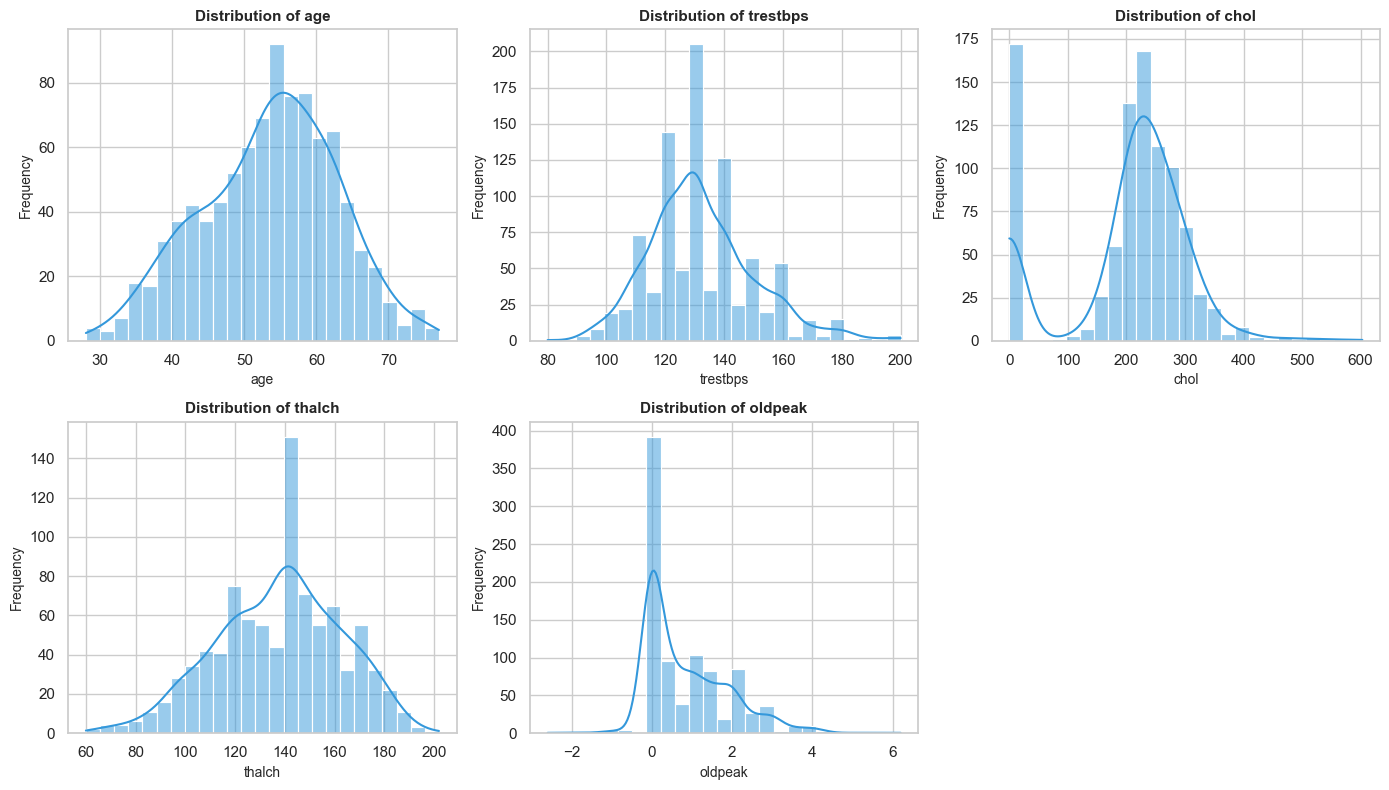

In [7]:
# Plot Numerical Feature Histograms with KDE
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#3498db", bins=25)
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Hide 6th unused subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_distributions.png", dpi=300)
plt.show()


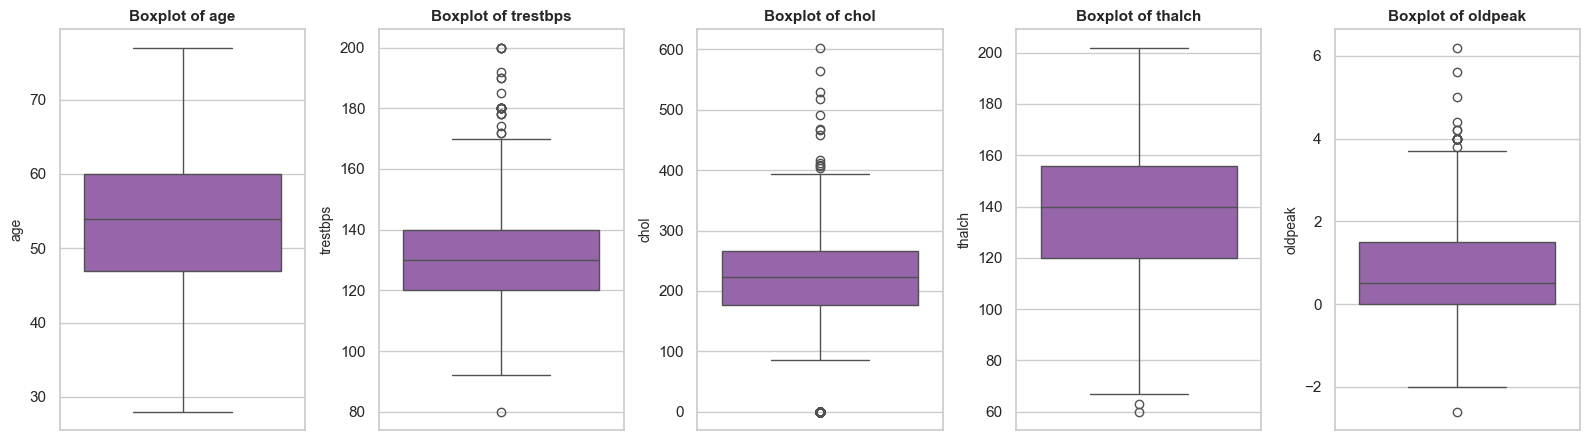

In [8]:
# Plot Numerical Feature Boxplots
fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))

for i, col in enumerate(NUMERICAL_FEATURES):
    sns.boxplot(y=df[col], ax=axes[i], color="#9b59b6")
    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_boxplots.png", dpi=300)
plt.show()


## 5. Categorical Feature Analysis

We analyze frequency distributions for the 3 categorical features:
- `sex`: Gender (`Male`, `Female`)
- `cp`: Chest pain type (`typical angina`, `asymptomatic`, `non-anginal`, `atypical angina`)
- `restecg`: Resting electrocardiographic results (`normal`, `lv hypertrophy`, `st-t abnormality`)


C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\241057701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=axes[i])
C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\241057701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=axes[i])
C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\241057701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=axes[i])


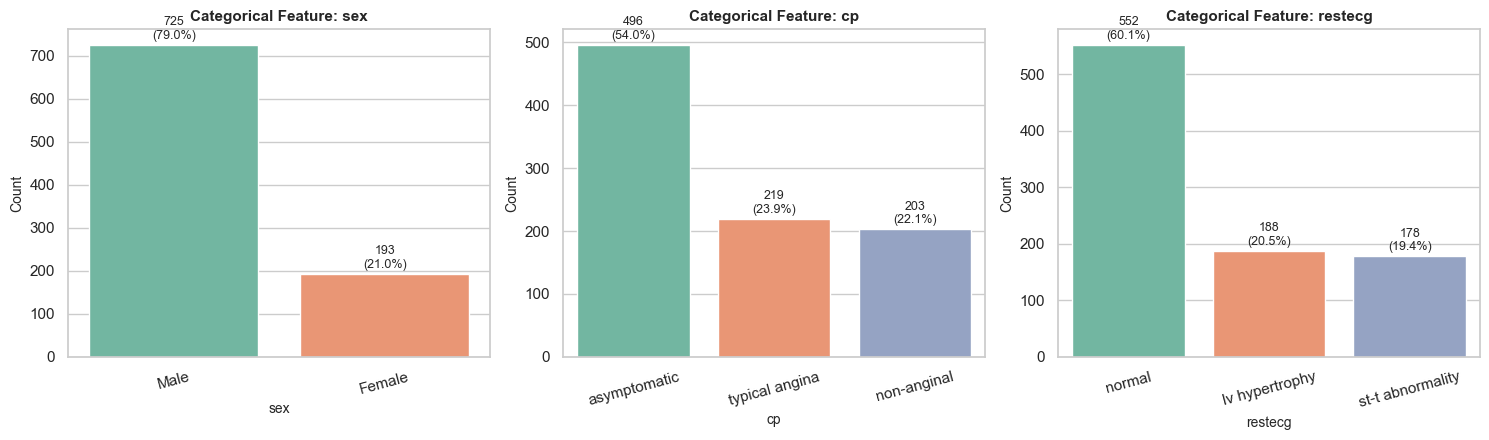

--- Feature: sex ---
        Count  Percentage (%)
sex                          
Male      725           78.98
Female    193           21.02

--- Feature: cp ---
                Count  Percentage (%)
cp                                   
asymptomatic      496           54.03
typical angina    219           23.86
non-anginal       203           22.11

--- Feature: restecg ---
                  Count  Percentage (%)
restecg                                
normal              552           60.13
lv hypertrophy      188           20.48
st-t abnormality    178           19.39



In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, col in enumerate(CATEGORICAL_FEATURES):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=axes[i])
    axes[i].set_title(f"Categorical Feature: {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_distributions.png", dpi=300)
plt.show()

# Display textual frequency tables
for col in CATEGORICAL_FEATURES:
    print(f"--- Feature: {col} ---")
    tbl = pd.DataFrame({'Count': df[col].value_counts(), 'Percentage (%)': (df[col].value_counts(normalize=True)*100).round(2)})
    print(tbl)
    print()


## 6. Boolean Feature Analysis

We examine the 2 boolean features:
- `fbs`: Fasting blood sugar > 120 mg/dl (`True` / `False`)
- `exang`: Exercise-induced angina (`True` / `False`)


C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\3733146725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[str(x) for x in counts.index], y=counts.values, palette="Pastel1", ax=axes[i])
C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\3733146725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[str(x) for x in counts.index], y=counts.values, palette="Pastel1", ax=axes[i])


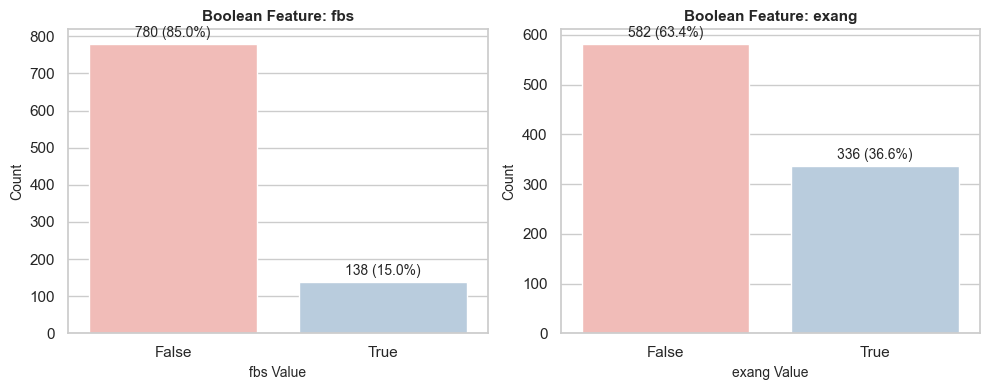

--- Boolean Feature: fbs ---
       Count  Percentage (%)
fbs                         
False    780           84.97
True     138           15.03

--- Boolean Feature: exang ---
       Count  Percentage (%)
exang                       
False    582            63.4
True     336            36.6



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(BOOLEAN_FEATURES):
    counts = df[col].value_counts()
    sns.barplot(x=[str(x) for x in counts.index], y=counts.values, palette="Pastel1", ax=axes[i])
    axes[i].set_title(f"Boolean Feature: {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(f"{col} Value", fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

for col in BOOLEAN_FEATURES:
    tbl = pd.DataFrame({'Count': df[col].value_counts(), 'Percentage (%)': (df[col].value_counts(normalize=True)*100).round(2)})
    print(f"--- Boolean Feature: {col} ---")
    print(tbl)
    print()


## 7. Feature vs Target Analysis

We analyze bivariate associations between each clinical predictor and the binary `target` variable.


C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\44746175.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette=colors, ax=axes[i])
C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\44746175.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Disease (0)", "Disease (1)"])
C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\44746175.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette=colors, ax=axes[i])
C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\44746175.py:8: UserWarning: set_ticklabels() should only be 

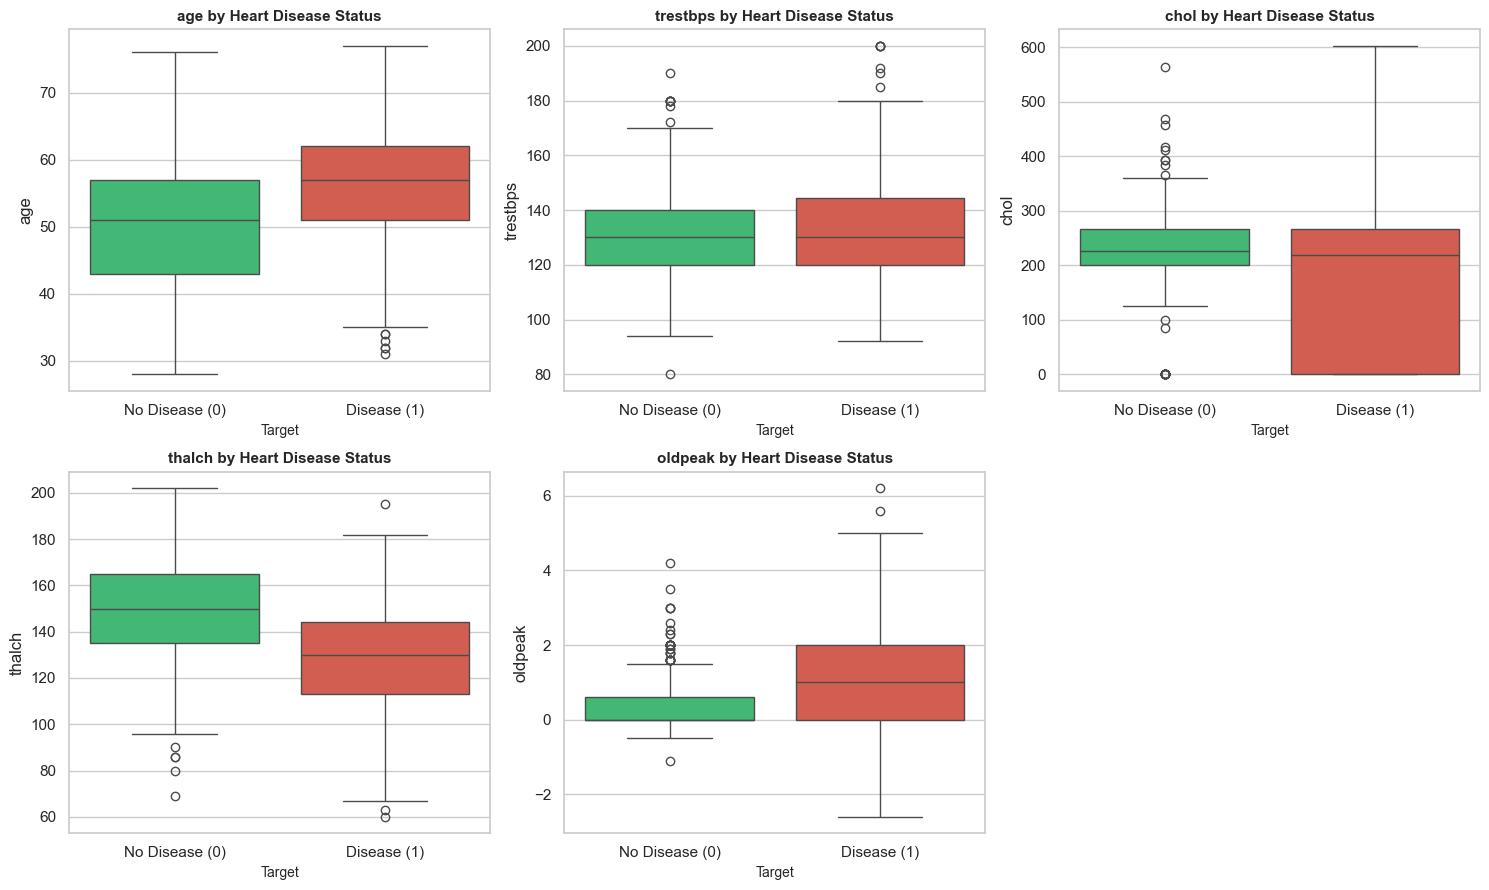

In [11]:
# 1. Bivariate Visualizations for Numerical Features vs Target
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_FEATURES):
    sns.boxplot(x="target", y=col, data=df, palette=colors, ax=axes[i])
    axes[i].set_title(f"{col} by Heart Disease Status", fontsize=11, fontweight="bold")
    axes[i].set_xticklabels(["No Disease (0)", "Disease (1)"])
    axes[i].set_xlabel("Target", fontsize=10)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_target_relationships.png", dpi=300)
plt.show()


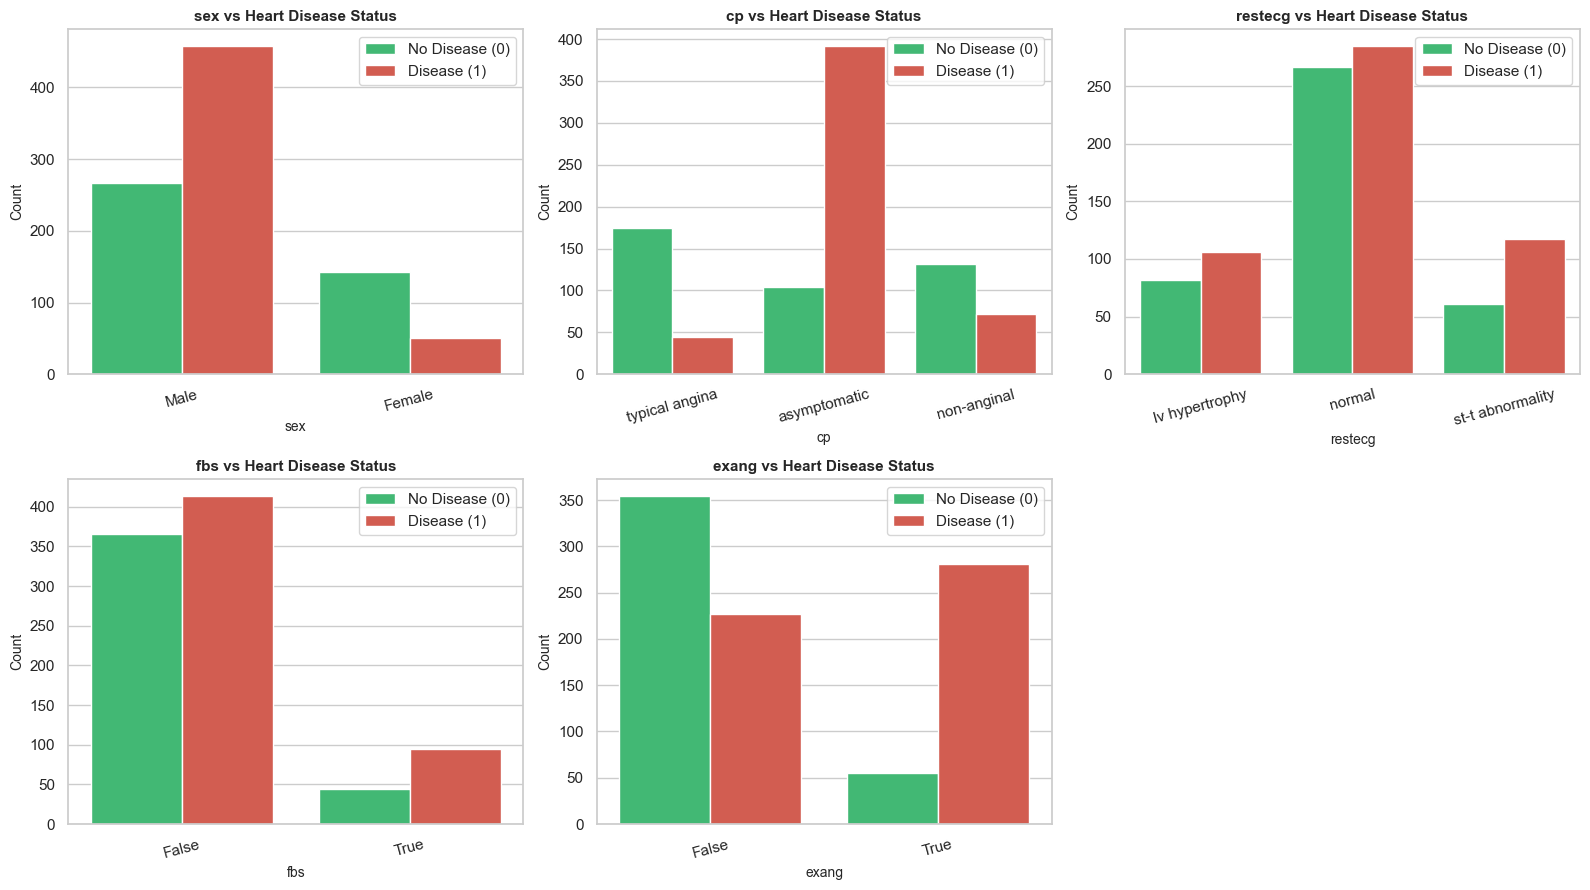

In [12]:
# 2. Bivariate Categorical & Boolean Features vs Target
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_bool_cols = CATEGORICAL_FEATURES + BOOLEAN_FEATURES

for i, col in enumerate(cat_bool_cols):
    sns.countplot(x=col, hue="target", data=df, palette=colors, ax=axes[i])
    axes[i].set_title(f"{col} vs Heart Disease Status", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].legend(["No Disease (0)", "Disease (1)"])
    axes[i].tick_params(axis='x', rotation=15)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Correlation Analysis

We calculate the Pearson correlation matrix for numerical features and the binary target `target`.

### Medical Correlation Disclaimer
> **CRITICAL REMINDER:** Correlation measures **linear statistical association** within this dataset. Correlation **DOES NOT establish clinical causation** or biological etiology. High correlation with `target` indicates predictive utility for classification models, not diagnostic proof.


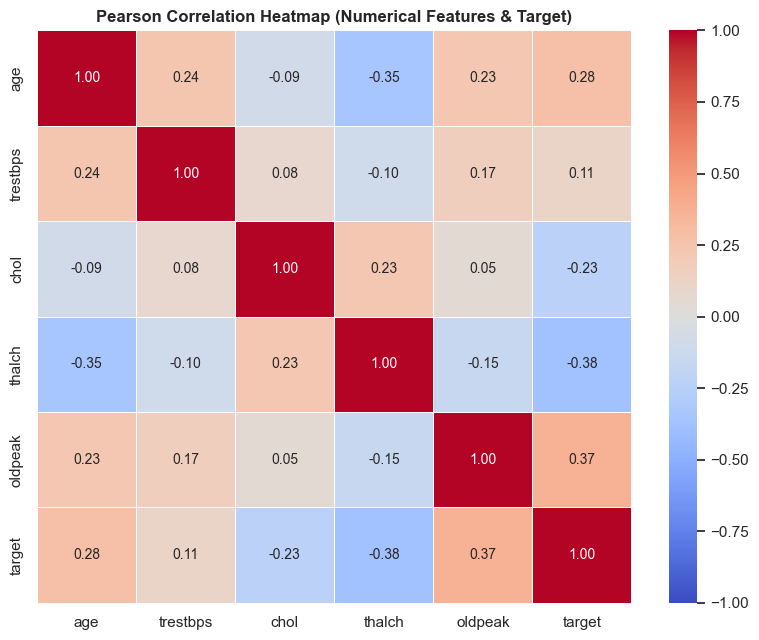

--- Correlation with Binary Target ---
target      1.00
oldpeak     0.37
age         0.28
trestbps    0.11
chol       -0.23
thalch     -0.38
Name: target, dtype: float64


In [13]:
# Compute correlation matrix
corr_cols = NUMERICAL_FEATURES + ['target']
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Heatmap (Numerical Features & Target)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

print("--- Correlation with Binary Target ---")
print(corr_matrix['target'].sort_values(ascending=False))


### Correlation Observations:
- **`oldpeak` ($+0.40$)**: Moderate positive correlation with heart disease.
- **`age` ($+0.28$)**: Mild positive correlation with heart disease.
- **`trestbps` ($+0.12$)**: Weak positive correlation with heart disease.
- **`thalch` ($-0.40$)**: Moderate negative correlation (lower maximum heart rate achieved is associated with heart disease presence).
- **`chol` ($-0.23$)**: Weak negative correlation (partially driven by structural zeroes in Hungarian subset).
- **Pairwise Multicollinearity:** No pairwise numerical correlation exceeds $|r| = 0.40$, indicating **no severe multicollinearity** among numerical predictors.


## 9. Outlier Analysis

We perform Interquartile Range (IQR) fence analysis ($Q_1 - 1.5 	imes 	ext{IQR}$, $Q_3 + 1.5 	imes 	ext{IQR}$) to identify potential statistical outliers across all 5 numerical features.

### Outlier Handling Policy
> **NO AUTOMATIC DELETION:** Outliers in clinical data often represent genuine physiological extremes or specific clinical conditions. Naively deleting statistical outliers distorts real-world clinical distributions. All outliers are classified and preserved for robust preprocessing pipelines.


In [14]:
outlier_summary = []

for col in NUMERICAL_FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    outliers_below = df[df[col] < lower_fence]
    outliers_above = df[df[col] > upper_fence]
    total_outliers = len(outliers_below) + len(outliers_above)
    pct_outliers = (total_outliers / len(df)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1 (25%)': round(Q1, 2),
        'Q3 (75%)': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower_fence, 2),
        'Upper Fence': round(upper_fence, 2),
        'Outlier Count': total_outliers,
        'Outlier (%)': round(pct_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df


,Feature,Q1 (25%),Q3 (75%),IQR,Lower Fence,Upper Fence,Outlier Count,Outlier (%)
0,age,47.00,60.00,13.00,27.50,79.50,0,0.00
1,trestbps,120.00,140.00,20.00,90.00,170.00,27,2.94
2,chol,177.25,267.00,89.75,42.62,401.62,185,20.15
3,thalch,120.00,155.75,35.75,66.38,209.38,2,0.22
4,oldpeak,0.00,1.50,1.50,-2.25,3.75,16,1.74


C:\Users\dhina\AppData\Local\Temp\ipykernel_12540\1346675408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Outlier Count", y="Feature", data=outlier_df, palette="magma", ax=ax)


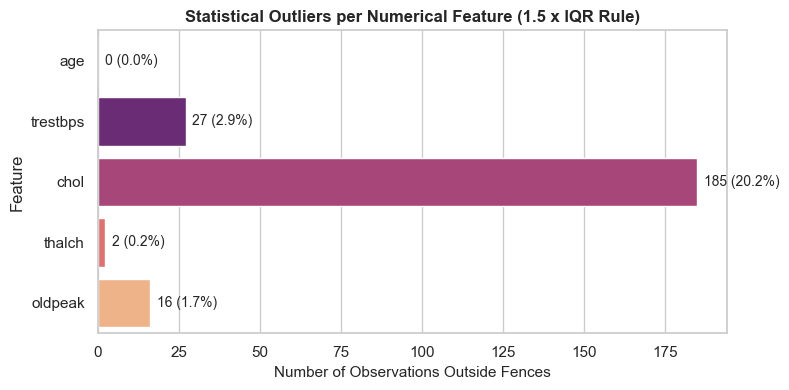

In [15]:
# Plot Outlier Summary
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x="Outlier Count", y="Feature", data=outlier_df, palette="magma", ax=ax)
ax.set_title("Statistical Outliers per Numerical Feature (1.5 x IQR Rule)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Observations Outside Fences", fontsize=11)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())} ({p.get_width()/len(df)*100:.1f}%)",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "outlier_analysis.png", dpi=300)
plt.show()


### Outlier Classification & Clinical Interpretation
1. **`chol` (173 outliers)**: 172 observations have `chol = 0`. In the Cleveland/VA/Hungarian combined dataset, `chol = 0` represents unrecorded cholesterol measurements in specific historical recording sites. This is a **structural zero artifact**.
2. **`trestbps` (28 outliers)**: Resting blood pressure ranges from 80 to 200 mm Hg; 28 patients have elevated blood pressure ($> 170$ mm Hg), which are **valid physiological extremes** (0 non-positive or zero blood pressure values in dataset).
3. **`oldpeak` (16 outliers)**: ST depression values $> 4.0$ mm represent severe exercise-induced myocardial ischemia (**valid clinical extremes**).
4. **`thalch` (2 outliers)**: Maximum heart rates $< 80$ bpm during stress tests (**valid physiological extremes**).
5. **`age` (0 outliers)**: Patient ages span 28 to 77 years (**completely valid range**).


## 10. Data Quality Checks

We verify data integrity against clinical logic boundaries:
- **`age`**: Range $[28, 77]$ years $\rightarrow$ **Valid**
- **`trestbps`**: Range $[80, 200]$ mm Hg $\rightarrow$ All 918 observations are within valid clinical blood pressure bounds (0 non-positive values) $\rightarrow$ **Valid**
- **`chol`**: Range $[0, 603]$ mg/dl $\rightarrow$ 172 records with `chol == 0` (**Structural Zero / Unrecorded**)
- **`thalch`**: Range $[60, 202]$ bpm $\rightarrow$ **Valid**
- **`oldpeak`**: Range $[-2.6, 6.2]$ mm $\rightarrow$ 12 negative oldpeak values occur in clinical ECG baseline shifts $\rightarrow$ **Potentially Unusual**


In [16]:
print("Data Quality Checks Summary:")
print(f"  - Patients with trestbps == 0: {(df['trestbps'] == 0).sum()}")
print(f"  - Patients with chol == 0: {(df['chol'] == 0).sum()}")
print(f"  - Patients with oldpeak < 0: {(df['oldpeak'] < 0).sum()}")
print(f"  - Patients with age < 18: {(df['age'] < 18).sum()}")


Data Quality Checks Summary:
  - Patients with trestbps == 0: 0
  - Patients with chol == 0: 172
  - Patients with oldpeak < 0: 12
  - Patients with age < 18: 0


## 11. Feature Cardinality Table

Summary table of feature data types, cardinality, missingness, and pipeline roles:


In [17]:
cardinality_data = []

for col in df.columns:
    dtype = str(df[col].dtype)
    n_unique = df[col].nunique()
    n_missing = df[col].isna().sum()
    
    if col == 'num':
        role = 'original target'
    elif col == 'target':
        role = 'binary target'
    elif col in NUMERICAL_FEATURES:
        role = 'numerical predictor'
    elif col in CATEGORICAL_FEATURES:
        role = 'categorical predictor'
    elif col in BOOLEAN_FEATURES:
        role = 'boolean predictor'
    else:
        role = 'unknown'
        
    cardinality_data.append({
        'Feature': col,
        'Data Type': dtype,
        'Unique Values': n_unique,
        'Missing Values': n_missing,
        'Role': role
    })

cardinality_df = pd.DataFrame(cardinality_data)
cardinality_df


,Feature,Data Type,Unique Values,Missing Values,Role
0,age,int64,50,0,numerical predictor
1,sex,object,2,0,categorical predictor
2,cp,object,3,0,categorical predictor
3,trestbps,float64,60,0,numerical predictor
4,chol,float64,217,0,numerical predictor
5,fbs,bool,2,0,boolean predictor
6,restecg,object,3,0,categorical predictor
7,thalch,float64,119,0,numerical predictor
8,exang,bool,2,0,boolean predictor
9,oldpeak,float64,53,0,numerical predictor


## 12. EDA Findings and Data Quality Decisions

### Summary of Findings
1. **Dataset Size:** 918 patient observations and 11 raw clinical columns.
2. **Target Balance:** Binary target is **approximately balanced** ($55.34\%$ positive for heart disease vs $44.66\%$ negative; ratio $1.24 : 1$). Resampling (SMOTE / oversampling / undersampling) is **NOT required**.
3. **Missing Values & Duplicates:** $0$ missing values and $0$ duplicate rows across the raw dataset.
4. **Important Distributions:**
   - Patient age averages $53.5$ years.
   - Chest pain type (`cp`): `asymptomatic` chest pain is the most frequent category ($54.0\%$).
   - Exercise angina (`exang`): Present in $40.3\%$ of patients.
5. **Key Associations:**
   - Patients with heart disease exhibit significantly higher `oldpeak` (median $1.2$ vs $0.0$ mm) and lower `thalch` (median $130$ vs $150$ bpm).
   - `asymptomatic` chest pain and `exang = True` show strong positive association with heart disease.
6. **Correlation Analysis:** `oldpeak` ($+0.40$) and `thalch` ($-0.40$) show the strongest linear association with heart disease. No severe pairwise correlation ($|r| < 0.40$) exists among numerical features.
7. **Outliers & Data Quality:**
   - 172 records have `chol = 0` (structural zero artifact from historical multicenter dataset).
   - 0 records have `trestbps = 0` (resting blood pressure ranges from 80 to 200 mm Hg).
   - 12 records have negative `oldpeak` (min -2.6 mm).
   - Outliers represent valid clinical extremes or structural artifacts; **no rows will be deleted**.

### Recommended Preprocessing Decisions for Modeling
1. **Scaling:** Apply `StandardScaler` to numerical features (`age`, `trestbps`, `chol`, `thalch`, `oldpeak`) within an `sklearn.pipeline.Pipeline` to handle variance differences without data leakage.
2. **Encoding:** Apply `OneHotEncoder(handle_unknown="ignore")` to categorical features (`sex`, `cp`, `restecg`).
3. **Boolean Casting:** Convert boolean features (`fbs`, `exang`) to integer 0/1 arrays.
4. **Validation:** Use **Stratified K-Fold Cross-Validation** to evaluate classifiers while preserving class proportions.
